In [1]:
import pandas as pd
import requests
from datetime import datetime, timedelta

# Получаем сегодняшнюю и стартовую дату
end_date = datetime.now()
start_date = end_date - timedelta(days=5 * 365)  # 5 лет назад

# Функция для загрузки исторических данных с MOEX
def download_moex_data(ticker, start_date, end_date):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/securities/{ticker}.json"

    all_data = []
    start = 0

    while True:
        params = {
            'from': start_date.strftime('%Y-%m-%d'),
            'till': end_date.strftime('%Y-%m-%d'),
            'interval': 24,  # дневной интервал
            'start': start
        }

        r = requests.get(url, params=params)
        d = r.json()

        columns = d['history']['columns']
        data = d['history']['data']

        if not data:
            break

        df = pd.DataFrame(data, columns=columns)
        all_data.append(df)

        # Переход к следующей странице
        start += 100

    return pd.concat(all_data, ignore_index=True)

# Пример: загрузка данных по Лукойлу (LKOH)
ticker = 'LKOH'
data = download_moex_data(ticker, start_date, end_date)

# Преобразуем дату и установим индекс
data['TRADEDATE'] = pd.to_datetime(data['TRADEDATE'])
data.set_index('TRADEDATE', inplace=True)

# Оставим только интересующие столбцы: открытие, максимум, минимум, закрытие, объем
columns_of_interest = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']
data = data[columns_of_interest]

# Выводим результат
print(data.head())

              OPEN    HIGH     LOW   CLOSE   VOLUME
TRADEDATE                                          
2020-05-13     NaN     NaN     NaN     NaN        0
2020-05-13  4877.5  4896.0  4815.5  4819.0  1151391
2020-05-14     NaN     NaN     NaN     NaN        0
2020-05-14  4800.0  4870.0  4773.0  4870.0  1474143
2020-05-15     NaN     NaN     NaN     NaN        0


<ipython-input-1-365e54f6113a>:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(all_data, ignore_index=True)


In [3]:
import pandas as pd
import requests
from datetime import datetime, timedelta
import os

# Папка для сохранения файлов
output_folder = "moex_data"
os.makedirs(output_folder, exist_ok=True)

# Даты: последние 5 лет
end_date = datetime.now()
start_date = end_date - timedelta(days=5 * 365)

# Список тикеров и рыноков
tickers = {

    "SU26228RMFS5": "bonds"     # ОФЗ 26228
}

# Функция выгрузки данных
def download_moex_data(ticker, market, start_date, end_date):
    url = f"https://iss.moex.com/iss/history/engines/stock/markets/{market}/securities/{ticker}.json"
    all_data = []
    start = 0

    while True:
        params = {
            'from': start_date.strftime('%Y-%m-%d'),
            'till': end_date.strftime('%Y-%m-%d'),
            'interval': 24,
            'start': start
        }

        response = requests.get(url, params=params)
        data = response.json()
        rows = data['history']['data']
        columns = data['history']['columns']

        if not rows:
            break

        df = pd.DataFrame(rows, columns=columns)
        all_data.append(df)
        start += 100

    if all_data:
        result = pd.concat(all_data, ignore_index=True)
        result['TRADEDATE'] = pd.to_datetime(result['TRADEDATE'])
        result.set_index('TRADEDATE', inplace=True)

        # Оставим ключевые столбцы, если есть
        cols = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']
        existing_cols = [col for col in cols if col in result.columns]
        return result[existing_cols]
    else:
        return pd.DataFrame()

# Выгрузка по всем тикерам
for ticker, market in tickers.items():
    print(f"Загружаем данные для {ticker} ({market})...")
    df = download_moex_data(ticker, market, start_date, end_date)

    if not df.empty:
        filepath = os.path.join(output_folder, f"{ticker}_moex_5y.xlsx")
        df.to_excel(filepath)
        print(f"Сохранено в файл: {filepath}")
    else:
        print(f"Данные для {ticker} не найдены или отсутствуют.")

Загружаем данные для SU26228RMFS5 (bonds)...
Сохранено в файл: moex_data/SU26228RMFS5_moex_5y.xlsx


<ipython-input-3-b31d25c2b6c7>:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result = pd.concat(all_data, ignore_index=True)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Путь к папке с файлами
data_dir = Path('Данные')

# Список файлов и тикеров
files = {
    "GMKN": "GMKN_moex_5y.xlsx",
    "LKOH": "LKOH_moex_5y.xlsx",
    "MGNT": "MGNT_moex_5y.xlsx",
    "SBER": "SBER_moex_5y.xlsx",
    "YNDX": "YNDX_moex_5y.xlsx",
    "SU26228RMFS": "SU26228RMFS5_moex_5y.xlsx"  # Облигация
}

# Загружаем данные и выбираем 'CLOSE'
prices = {}
for ticker, filename in files.items():
    df = pd.read_excel(data_dir / filename, index_col=0, parse_dates=True)
    if 'CLOSE' in df.columns:
        # Удаляем дубликаты по индексу (датам), оставляя первое значение
        df = df[~df.index.duplicated(keep='first')]
        prices[ticker] = df['CLOSE']

# Объединяем все в один DataFrame
price_df = pd.DataFrame(prices).dropna()

# Считаем дневную доходность
returns = price_df.pct_change().dropna()

# Пример весов (произвольные, сумма = 1)
weights = np.array([0.2, 0.2, 0.15, 0.15, 0.2, 0.1])  # GMKN, LKOH, MGNT, SBER, YNDX, ОФЗ

# Начальный капитал
initial_investment = 50_000

# Считаем доходность портфеля
portfolio_returns = returns.dot(weights)

# Вычисляем стоимость портфеля во времени
portfolio_value = (1 + portfolio_returns).cumprod() * initial_investment

# Строим график стоимости портфеля
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value, label="Portfolio Value")
plt.title("Динамика стоимости портфеля (последние 5 лет)")
plt.xlabel("Дата")
plt.ylabel("Руб.")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Данные/GMKN_moex_5y.xlsx'

In [8]:
cov_matrix = returns.cov()
cov_matrix

,GMKN,LKOH,MGNT,SBER,YNDX,SU26228RMFS
GMKN,0.001392,0.000178,0.000184,0.000210,0.000203,0.000041
LKOH,0.000178,0.000436,0.000236,0.000287,0.000290,0.000047
MGNT,0.000184,0.000236,0.000467,0.000299,0.000320,0.000067
SBER,0.000210,0.000287,0.000299,0.000752,0.000382,0.000076
YNDX,0.000203,0.000290,0.000320,0.000382,0.000783,0.000076
SU26228RMFS,0.000041,0.000047,0.000067,0.000076,0.000076,0.000045


In [12]:
# 1. Средняя доходность по каждому активу
avg_rets = returns.mean()

# 2. Средняя доходность портфеля
port_mean = avg_rets.dot(weights)

# 3. Ковариационная матрица доходностей
cov_matrix = returns.cov()

# 4. Стандартное отклонение (риск) портфеля
port_stdev = np.sqrt(weights.T.dot(cov_matrix).dot(weights))

# 5. Ожидаемая стоимость инвестиций через год (или за период усреднения доходности)
mean_investment = (1 + port_mean) * initial_investment

# 6. Отклонение стоимости портфеля (в рублях)
stdev_investment = initial_investment * port_stdev

# 7. Вывод результатов
print(f"Средняя доходность портфеля: {port_mean:.4%}")
print(f"Стандартное отклонение портфеля: {port_stdev:.4%}")
print(f"Ожидаемая стоимость портфеля: {mean_investment:,.2f} руб.")
print(f"Ожидаемое отклонение: ±{stdev_investment:,.2f} руб.")

Средняя доходность портфеля: 0.0205%
Стандартное отклонение портфеля: 1.7531%
Ожидаемая стоимость портфеля: 50,010.27 руб.
Ожидаемое отклонение: ±876.54 руб.


In [13]:
from scipy.stats import norm

# Уровень значимости (1% -> 99% доверительный уровень)
conf_level1 = 0.01

# Получаем квантиль (z-значение) для нормального распределения
z_score = norm.ppf(conf_level1)

# Переводим это в денежные потери от начального капитала
# (ожидаемый убыток при худшем 1% сценарии)
var_1d1 = -(port_mean + z_score * port_stdev) * initial_investment

# Вывод
print(f"1-Day VaR (99%): {var_1d1:,.2f} руб.")


1-Day VaR (99%): 2,028.86 руб.


Это максимальный ожидаемый убыток за 1 день с вероятностью 99%

1 day VaR @ 95% confidence: 1,431.50 руб.
2 day VaR @ 95% confidence: 2,024.45 руб.
3 day VaR @ 95% confidence: 2,479.44 руб.
4 day VaR @ 95% confidence: 2,863.01 руб.
5 day VaR @ 95% confidence: 3,200.94 руб.
6 day VaR @ 95% confidence: 3,506.46 руб.
7 day VaR @ 95% confidence: 3,787.41 руб.
8 day VaR @ 95% confidence: 4,048.91 руб.
9 day VaR @ 95% confidence: 4,294.51 руб.
10 day VaR @ 95% confidence: 4,526.82 руб.
11 day VaR @ 95% confidence: 4,747.76 руб.
12 day VaR @ 95% confidence: 4,958.88 руб.
13 day VaR @ 95% confidence: 5,161.36 руб.
14 day VaR @ 95% confidence: 5,356.20 руб.
15 day VaR @ 95% confidence: 5,544.19 руб.


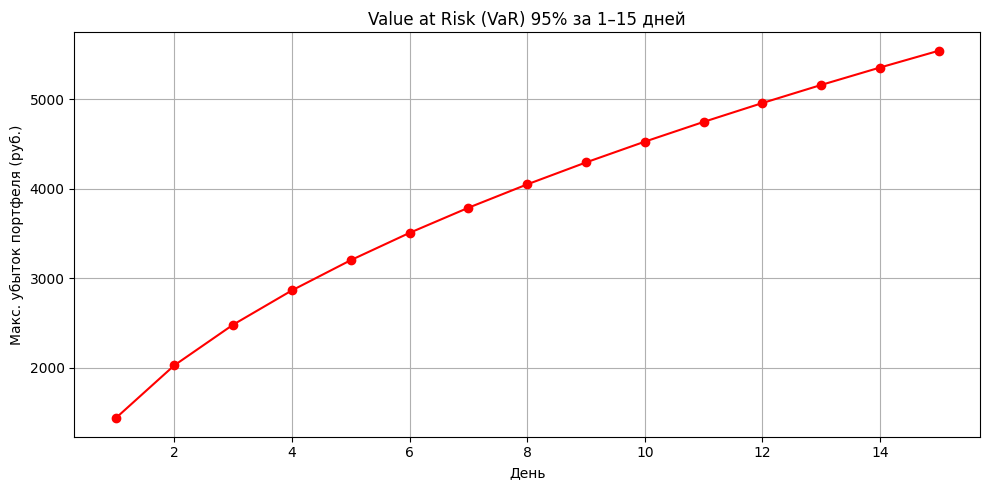

In [14]:
from scipy.stats import norm

# Новый уровень доверия: 95%
conf_level_95 = 0.05
z_95 = norm.ppf(conf_level_95)

# VaR на 1 день при 95% доверии
var_1d_95 = -(port_mean + z_95 * port_stdev) * initial_investment

# Расчёт VaR на 1–15 дней
var_array = []
num_days = 15

for x in range(1, num_days + 1):
    var_t = np.round(var_1d_95 * np.sqrt(x), 2)
    var_array.append(var_t)
    print(f"{x} day VaR @ 95% confidence: {var_t:,.2f} руб.")

# График
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_days + 1), var_array, color='red', marker='o')
plt.xlabel("День")
plt.ylabel("Макс. убыток портфеля (руб.)")
plt.title("Value at Risk (VaR) 95% за 1–15 дней")
plt.grid(True)
plt.tight_layout()
plt.show()

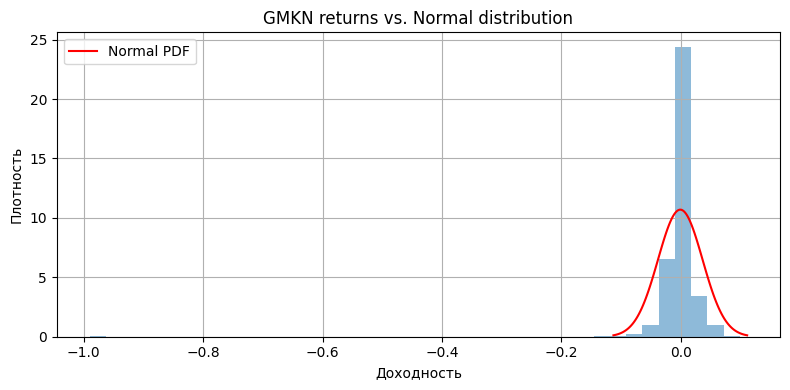

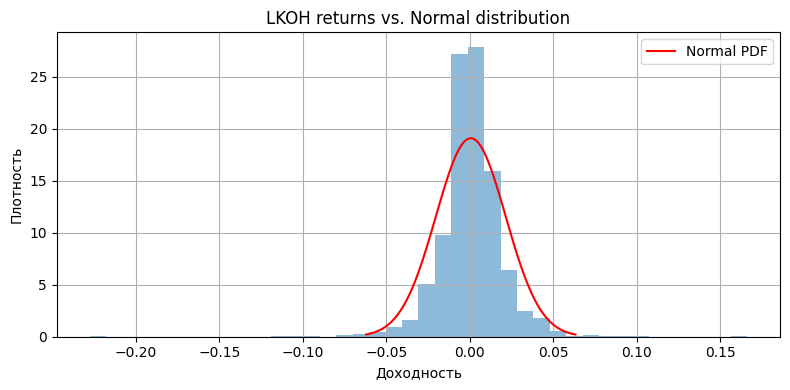

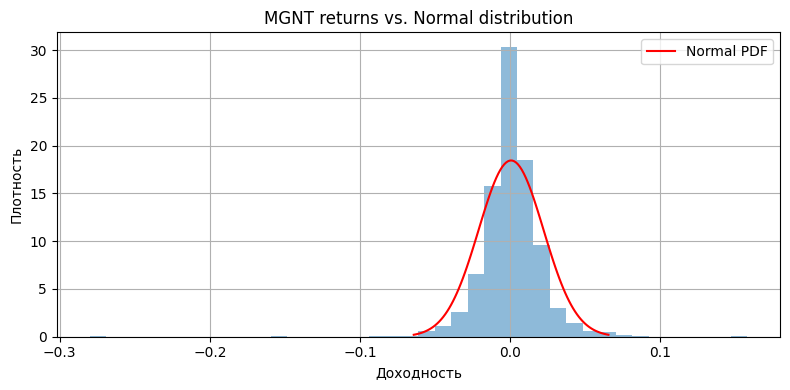

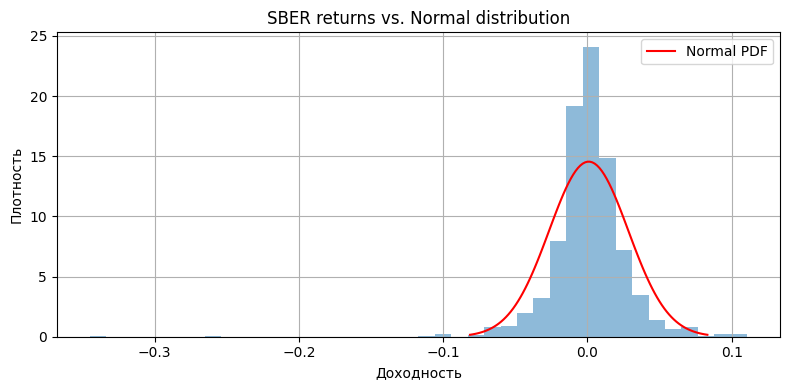

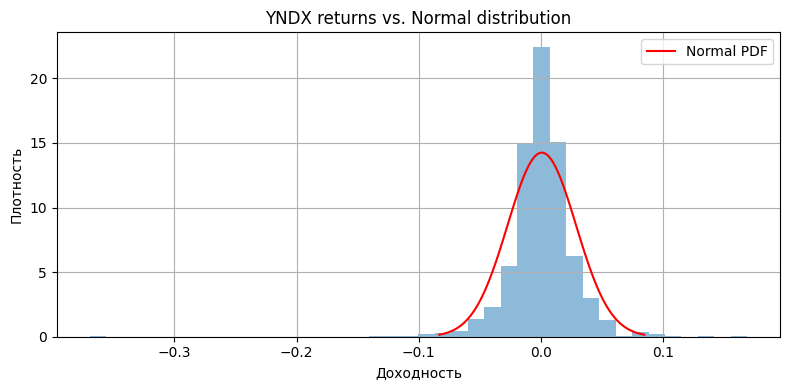

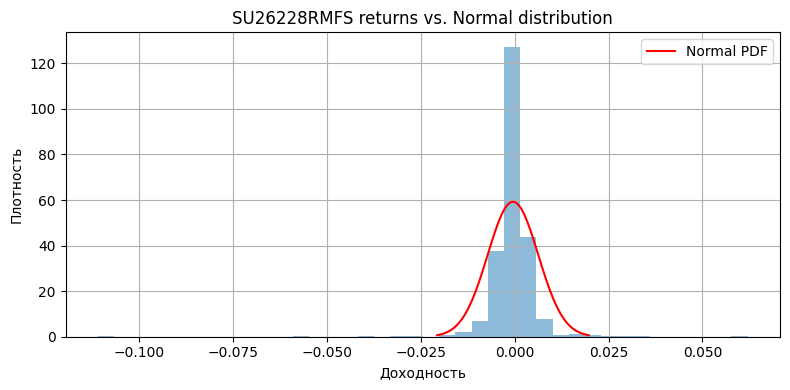

In [15]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

# Построим графики нормальности для всех активов
for ticker in returns.columns:
    plt.figure(figsize=(8, 4))

    # Гистограмма доходностей
    returns[ticker].hist(bins=40, histtype="stepfilled", alpha=0.5, density=True)

    # Параметры нормального распределения
    mean = returns[ticker].mean()
    std_dev = returns[ticker].std()

    # Нормальное распределение поверх гистограммы
    x = np.linspace(mean - 3*std_dev, mean + 3*std_dev, 100)
    plt.plot(x, norm.pdf(x, mean, std_dev), "r", label="Normal PDF")


    plt.title(f"{ticker} returns vs. Normal distribution")
    plt.xlabel("Доходность")
    plt.ylabel("Плотность")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


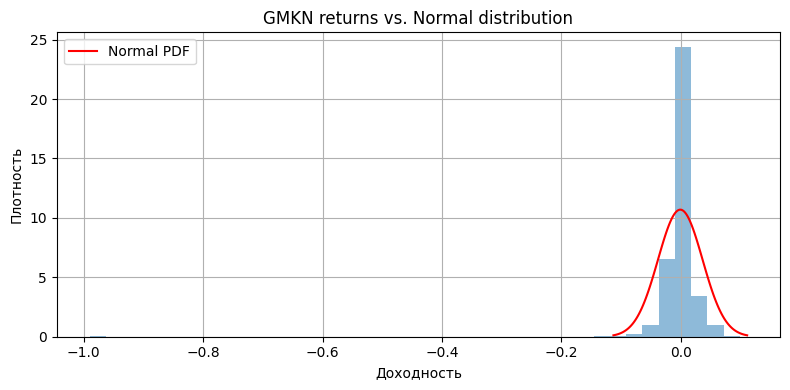

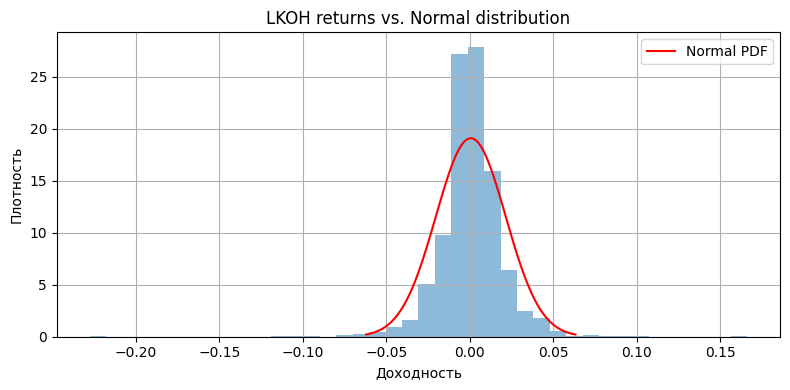

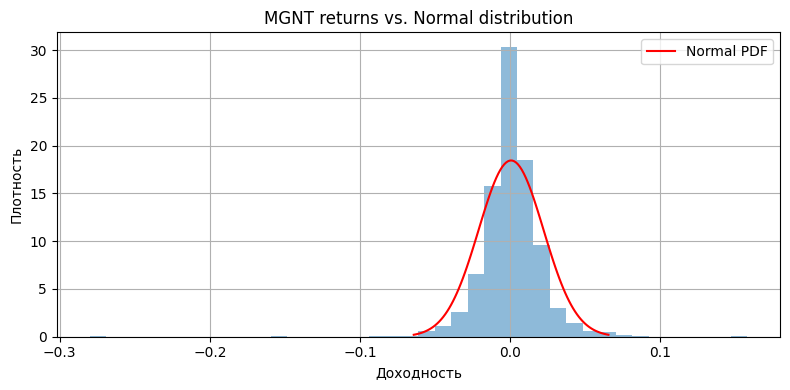

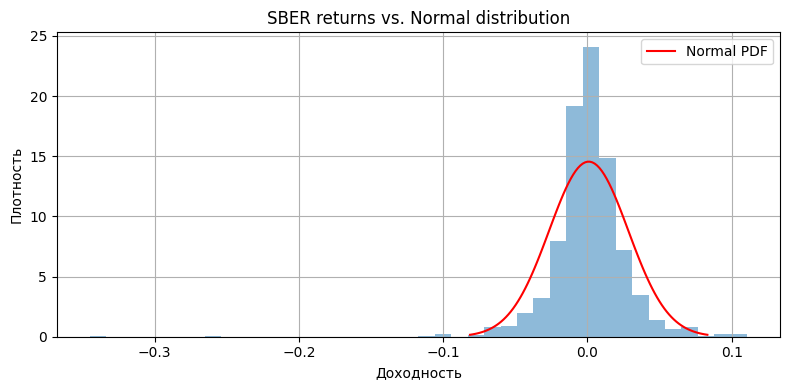

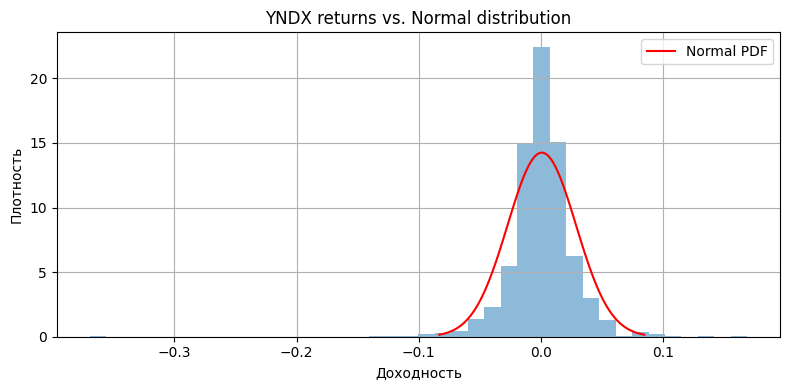

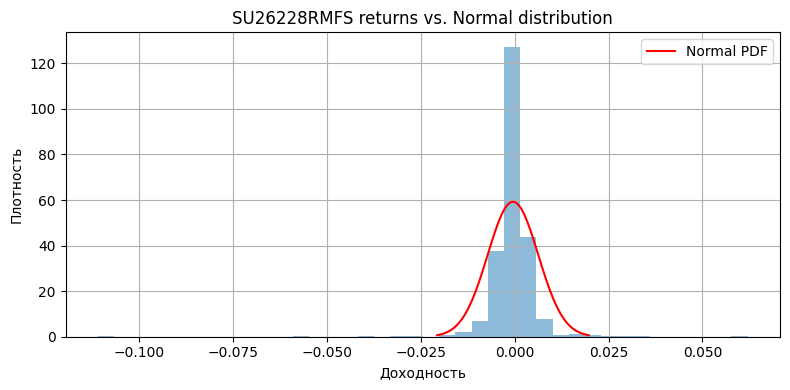

        Ticker  Shapiro-Wilk p  Jarque-Bera p  Anderson-Darling stat  \
0         GMKN             0.0            0.0               102.9078   
1         LKOH             0.0            0.0                23.8462   
2         MGNT             0.0            0.0                22.0968   
3         SBER             0.0            0.0                25.9022   
4         YNDX             0.0            0.0                22.3837   
5  SU26228RMFS             0.0            0.0                74.3524   

   AD 5% crit AD normal?  
0       0.784     Reject  
1       0.784     Reject  
2       0.784     Reject  
3       0.784     Reject  
4       0.784     Reject  
5       0.784     Reject  


In [17]:
from scipy.stats import norm, shapiro, jarque_bera, anderson
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Список для хранения результатов тестов
normality_results = []

# Цикл по каждому активу
for ticker in returns.columns:
    data = returns[ticker].dropna()

    # Строим гистограмму с кривой нормального распределения
    plt.figure(figsize=(8, 4))
    data.hist(bins=40, histtype="stepfilled", alpha=0.5, density=True)

    mean = data.mean()
    std_dev = data.std()
    x = np.linspace(mean - 3*std_dev, mean + 3*std_dev, 100)
    plt.plot(x, norm.pdf(x, mean, std_dev), "r", label="Normal PDF")
    plt.title(f"{ticker} returns vs. Normal distribution")
    plt.xlabel("Доходность")
    plt.ylabel("Плотность")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Тесты нормальности ---
    # Shapiro-Wilk
    shapiro_stat, shapiro_p = shapiro(data)
    # Jarque-Bera
    jb_stat, jb_p = jarque_bera(data)
    # Anderson-Darling (возвращает критические значения)
    anderson_result = anderson(data)
    ad_stat = anderson_result.statistic
    ad_crit_5pct = anderson_result.critical_values[2]  # уровень 5%
    ad_result = "Reject" if ad_stat > ad_crit_5pct else "Accept"

    # Добавляем в список результатов
    normality_results.append({
        "Ticker": ticker,
        "Shapiro-Wilk p": round(shapiro_p, 4),
        "Jarque-Bera p": round(jb_p, 4),
        "Anderson-Darling stat": round(ad_stat, 4),
        "AD 5% crit": round(ad_crit_5pct, 4),
        "AD normal?": ad_result
    })

# Выводим таблицу с результатами
normality_df = pd.DataFrame(normality_results)
print(normality_df)

Распределения доходностей всех активов в портфеле не соответствуют нормальному распределению.

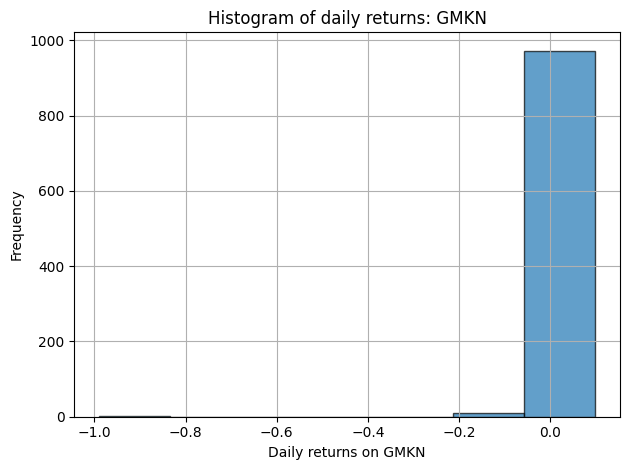

Frequency by bin for GMKN:
 GMKN
(-0.991, -0.834]       1
(-0.834, -0.679]       0
(-0.679, -0.523]       0
(-0.523, -0.368]       0
(-0.368, -0.212]       0
(-0.212, -0.0569]     10
(-0.0569, 0.0986]    973
Name: count, dtype: int64

Mean return for GMKN: -0.00112
Standard deviation for GMKN: 0.03729


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Выбери тикер (замени при необходимости)
ticker = "GMKN"

# Дневные доходности по выбранному активу
return_data = returns[ticker].dropna()

# Гистограмма (7 бинов)
plt.hist(return_data, bins=7, edgecolor='black', alpha=0.7)
plt.xlabel(f'Daily returns on {ticker}')
plt.ylabel('Frequency')
plt.title(f'Histogram of daily returns: {ticker}')
plt.grid(True)
plt.tight_layout()
plt.show()

# Частотное распределение по интервалам (bins)
bins = pd.cut(return_data, bins=7).value_counts().sort_index()
print(f"Frequency by bin for {ticker}:\n", bins)

# Статистики
print(f"\nMean return for {ticker}: {np.mean(return_data):.5f}")
print(f"Standard deviation for {ticker}: {np.std(return_data):.5f}")

In [19]:
from tabulate import tabulate

# Выбор актива
ticker = "GMKN"
return_data = returns[ticker].dropna()

# Сортировка доходностей (для наглядности, не обязательно для quantile())
return_data.sort_values(inplace=True)

# Расчет исторического VaR по квантилям
VaR_90 = return_data.quantile(0.10)
VaR_95 = return_data.quantile(0.05)
VaR_99 = return_data.quantile(0.01)

# Вывод таблицы
print(tabulate([
    ['90%', VaR_90],
    ['95%', VaR_95],
    ['99%', VaR_99]
], headers=['Confidence Level', 'Value at Risk (1-day return)']))

Confidence Level      Value at Risk (1-day return)
------------------  ------------------------------
90%                                     -0.0193697
95%                                     -0.0316748
99%                                     -0.0601235


In [39]:
import numpy as np

# Параметры
ticker = 'GMKN'
alpha = 0.01                     # для 99% доверительного уровня
num_shares = 10
on_date = '2024-01-11'

# Цена акции на выбранную дату
share_price = price_df[ticker].loc[on_date]

# Доходности
daily_return_rates = returns[ticker].dropna().sort_values().reset_index(drop=True)

# Индекс квантиля
xth = int(np.floor(alpha * len(daily_return_rates))) - 1
xth_smallest_rate = daily_return_rates.iloc[xth]

# Средняя доходность
mean_return_rate = daily_return_rates.mean()

# VaR: относительный и абсолютный
rel_VaR = num_shares * share_price * (mean_return_rate - xth_smallest_rate)
abs_VaR = -num_shares * share_price * xth_smallest_rate

# Вывод
print(f"The estimated relative VaR and absolute VaR of an investment of {num_shares} shares of {ticker} on {on_date} with price ₽{share_price:.2f} per share is:")
print(f"Relative VaR (vs mean return): ₽{rel_VaR:,.2f}")
print(f"Absolute VaR (worst-case loss): ₽{abs_VaR:,.2f}")


The estimated relative VaR and absolute VaR of an investment of 10 shares of GMKN on 2024-01-11 with price ₽16276.00 per share is:
Relative VaR (vs mean return): ₽10,574.72
Absolute VaR (worst-case loss): ₽10,756.34



📉 Metric (Normal) VaR estimates for GMKN on 2024-01-11 (₽16276.00/share):

Confidence Level      Relative VaR (₽)    Absolute VaR (₽)    VaR return threshold
------------------  ------------------  ------------------  ----------------------
90%                        3.89056e+06         3.98137e+06                -0.04892
95%                        4.99348e+06         5.08429e+06                -0.06248
99%                        7.06238e+06         7.15319e+06                -0.0879


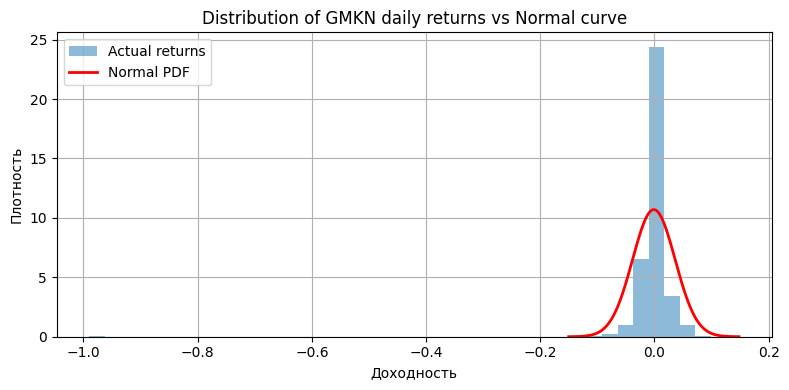

In [42]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

# Параметры
ticker = 'GMKN'
alpha_list = [0.10, 0.05, 0.01]  # уровни риска для 90%, 95%, 99%
num_shares = 5000
on_date = '2024-01-11'

# Получаем цену акции на дату
share_price = price_df[ticker].loc[on_date]

# Доходности
returns_data = returns[ticker].dropna()
mean = returns_data.mean()
std_dev = returns_data.std()

# Расчёт Z-значений и VaR
print(f"\n📉 Metric (Normal) VaR estimates for {ticker} on {on_date} (₽{share_price:.2f}/share):\n")
rows = []

for alpha in alpha_list:
    Z_value = norm.ppf(alpha)

    # Relative VaR: насколько хуже относительно среднего
    rel_VaR = -num_shares * share_price * Z_value * std_dev

    # Absolute VaR: ожидаемый убыток в худшем случае
    abs_VaR = -num_shares * share_price * (Z_value * std_dev + mean)

    rows.append([
        f"{int((1 - alpha)*100)}%",
        round(rel_VaR, 2),
        round(abs_VaR, 2),
        round(Z_value * std_dev + mean, 5)
    ])

print(tabulate(rows, headers=["Confidence Level", "Relative VaR (₽)", "Absolute VaR (₽)", "VaR return threshold"]))


# Построение распределения доходностей и нормальной кривой

plt.figure(figsize=(8, 4))
returns_data.hist(bins=40, histtype='stepfilled', alpha=0.5, density=True, label="Actual returns")

# Теоретическая кривая нормального распределения
x = np.linspace(mean - 4 * std_dev, mean + 4 * std_dev, 500)
plt.plot(x, norm.pdf(x, mean, std_dev), 'r', lw=2, label="Normal PDF")

plt.title(f"Distribution of {ticker} daily returns vs Normal curve")
plt.xlabel("Доходность")
plt.ylabel("Плотность")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Последние дневные доходности:
                GMKN      LKOH      MGNT      SBER      YNDX  SU26228RMFS
TRADEDATE                                                                
2024-06-07  0.009369  0.012301  0.007770  0.028063  0.004234     0.001123
2024-06-10  0.007066 -0.023234 -0.024318 -0.021338 -0.022833    -0.008230
2024-06-11  0.044986 -0.003418 -0.014286  0.012842 -0.005720     0.000872
2024-06-13 -0.061611 -0.015295  0.000771 -0.018380 -0.013164    -0.003036
2024-06-14  0.024972  0.026398  0.019874  0.023865  0.005731     0.000259


<Figure size 1200x600 with 0 Axes>

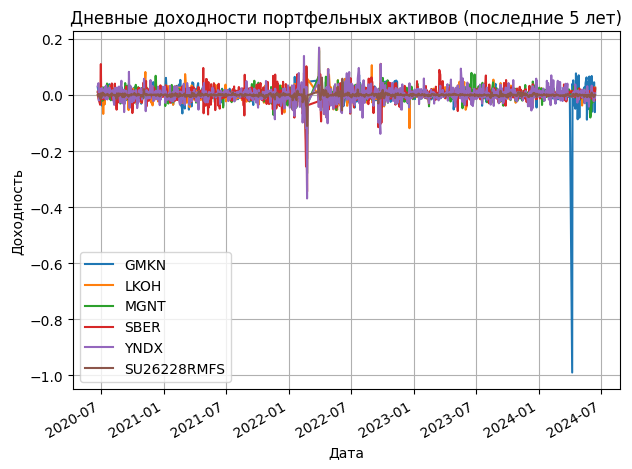

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Путь к данным
data_dir = Path("moex_data")

# Названия файлов и тикеров
files = {
    "GMKN": "GMKN_moex_5y.xlsx",
    "LKOH": "LKOH_moex_5y.xlsx",
    "MGNT": "MGNT_moex_5y.xlsx",
    "SBER": "SBER_moex_5y.xlsx",
    "YNDX": "YNDX_moex_5y.xlsx",
    "SU26228RMFS": "SU26228RMFS5_moex_5y.xlsx"
}

# Загрузка цен закрытия
prices = {}
for ticker, filename in files.items():
    df = pd.read_excel(data_dir / filename, index_col=0, parse_dates=True)
    if 'CLOSE' in df.columns:
        # удалим дубликаты по дате
        df = df[~df.index.duplicated(keep='first')]
        prices[ticker] = df['CLOSE']

# Объединение всех в один DataFrame
price_df = pd.DataFrame(prices).dropna()

# Расчёт доходностей
returns = price_df.pct_change().dropna()

# Просмотр последних значений
print("Последние дневные доходности:")
print(returns.tail())

# Построение графика доходностей
plt.figure(figsize=(12, 6))
returns.plot()
plt.title("Дневные доходности портфельных активов (последние 5 лет)")
plt.xlabel("Дата")
plt.ylabel("Доходность")
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# Генерация ковариационной матрицы
cov_matrix = returns.cov()

# Отображение матрицы
print("Ковариационная матрица дневных доходностей:")
print(cov_matrix.round(6))

Ковариационная матрица дневных доходностей:
                 GMKN      LKOH      MGNT      SBER      YNDX  SU26228RMFS
GMKN         0.001392  0.000178  0.000184  0.000210  0.000203     0.000041
LKOH         0.000178  0.000436  0.000236  0.000287  0.000290     0.000047
MGNT         0.000184  0.000236  0.000467  0.000299  0.000320     0.000067
SBER         0.000210  0.000287  0.000299  0.000752  0.000382     0.000076
YNDX         0.000203  0.000290  0.000320  0.000382  0.000783     0.000076
SU26228RMFS  0.000041  0.000047  0.000067  0.000076  0.000076     0.000045


In [45]:
import numpy as np
from scipy.optimize import minimize
# Количество активов
num_assets = len(returns.columns)

# Доходности и ковариация
mean_returns = returns.mean()
cov_matrix = returns.cov()
risk_free_rate = 0.0  # предположим безрисковую ставку ноль (можно изменить)

# Функция: стандартное отклонение (риск портфеля)
def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov_matrix @ weights)

# Функция: Sharpe Ratio (нужно максимизировать)
def neg_sharpe_ratio(weights):
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    return - (port_return - risk_free_rate) / port_vol
# Ограничение: сумма весов = 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Границы для весов (в диапазоне 0..1)
bounds = tuple((0, 1) for _ in range(num_assets))

# Начальные веса (равномерные)
initial_weights = np.array([1 / num_assets] * num_assets)
# Минимизация риска портфеля
min_vol_result = minimize(portfolio_volatility, initial_weights,
                          method='SLSQP', bounds=bounds,
                          constraints=constraints)

# Максимизация Sharpe Ratio
max_sharpe_result = minimize(neg_sharpe_ratio, initial_weights,
                             method='SLSQP', bounds=bounds,
                             constraints=constraints)
print("Минимальный риск портфеля:")
print("Weights:", np.round(min_vol_result.x, 4))
print("Volatility:", round(portfolio_volatility(min_vol_result.x), 4))

print("Максимальный Sharpe Ratio:")
print("Weights:", np.round(max_sharpe_result.x, 4))
print("Sharpe Ratio:", round(-neg_sharpe_ratio(max_sharpe_result.x), 4))


Минимальный риск портфеля:
Weights: [0.0031 0.     0.     0.     0.     0.9969]
Volatility: 0.0067
Максимальный Sharpe Ratio:
Weights: [0.     0.1123 0.5543 0.3334 0.     0.    ]
Sharpe Ratio: 0.0379


Портфель с минимальным риском ведёт к полной концентрации в наименее волатильном активе — государственной облигации. Это логично, но доходность у такого портфеля также низкая.

Оптимизация по Шарпу игнорирует облигации, так как они существенно снижают доходность. Выбор пал на акции, сочетающие умеренный риск и доходность.

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Входные данные
mean_returns = returns.mean()
cov_matrix = returns.cov()
num_assets = len(mean_returns)
num_portfolios = 10_000
risk_free_rate = 0.0

# Массивы для хранения результатов
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Генерация случайных весов
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    # Доходность и риск
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility

    # Сохраняем результаты
    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe_ratio
    weights_record.append(weights)

# Преобразуем в numpy array
weights_record = np.array(weights_record)

In [47]:
# Индекс максимального Sharpe Ratio
max_sharpe_idx = np.argmax(results[2])
# Индекс минимального риска
min_risk_idx = np.argmin(results[1])

# Весовые коэффициенты этих портфелей
max_sharpe_weights = weights_record[max_sharpe_idx]
min_risk_weights = weights_record[min_risk_idx]

print("Портфель с максимальным Sharpe Ratio:")
for i, ticker in enumerate(returns.columns):
    print(f"{ticker}: {max_sharpe_weights[i]:.2%}")
print(f"Sharpe Ratio: {results[2, max_sharpe_idx]:.4f}")

print("Портфель с минимальным риском:")
for i, ticker in enumerate(returns.columns):
    print(f"{ticker}: {min_risk_weights[i]:.2%}")
print(f"Volatility: {results[1, min_risk_idx]:.4f}")

Портфель с максимальным Sharpe Ratio:
GMKN: 0.71%
LKOH: 14.87%
MGNT: 43.43%
SBER: 37.30%
YNDX: 3.67%
SU26228RMFS: 0.02%
Sharpe Ratio: 0.0372
Портфель с минимальным риском:
GMKN: 8.81%
LKOH: 13.17%
MGNT: 19.29%
SBER: 3.08%
YNDX: 4.94%
SU26228RMFS: 50.70%
Volatility: 0.0110


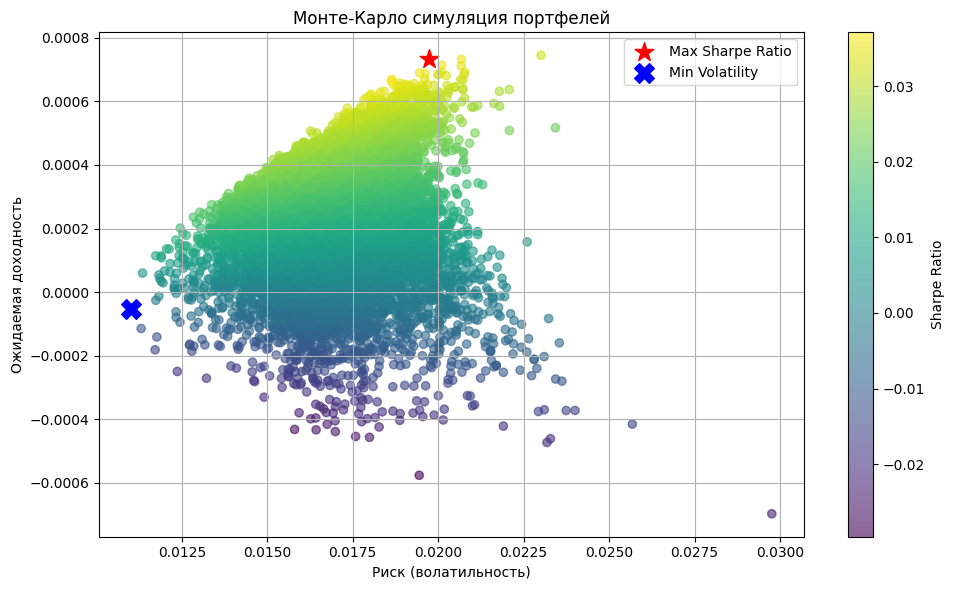

In [48]:
plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='viridis', alpha=0.6)
plt.colorbar(label='Sharpe Ratio')

# Выделим лучшие портфели
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], marker='*', color='r', s=200, label='Max Sharpe Ratio')
plt.scatter(results[1, min_risk_idx], results[0, min_risk_idx], marker='X', color='b', s=200, label='Min Volatility')

plt.title('Монте-Карло симуляция портфелей')
plt.xlabel('Риск (волатильность)')
plt.ylabel('Ожидаемая доходность')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
import numpy as np
from scipy.optimize import minimize

# Параметры
mean_returns = returns.mean()
cov_matrix = returns.cov()
num_assets = len(mean_returns)
risk_free_rate = 0.0

# Установим границы на веса активов (например, не более 40%, не менее 5%)
bounds = tuple((0.05, 0.3) for _ in range(num_assets))

# Сумма всех весов должна быть 1
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
initial_weights = np.array([1 / num_assets] * num_assets)

# Функция: отрицательное значение Sharpe Ratio
def neg_sharpe_ratio(weights):
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(weights.T @ cov_matrix @ weights)
    return - (port_return - risk_free_rate) / port_vol

# Функция: волатильность портфеля
def portfolio_volatility(weights):
    return np.sqrt(weights.T @ cov_matrix @ weights)

In [55]:
# Оптимизация на максимальный Sharpe Ratio с ограничениями на доли
opt_result = minimize(neg_sharpe_ratio, initial_weights,
                      method='SLSQP', bounds=bounds,
                      constraints=constraints)

# Альтернатива: минимизация риска
opt_result = minimize(portfolio_volatility, initial_weights,
                       method='SLSQP', bounds=bounds,
                       constraints=constraints)

In [56]:
optimal_weights = opt_result.x
sharpe = -neg_sharpe_ratio(optimal_weights)
volatility = portfolio_volatility(optimal_weights)
port_return = np.dot(optimal_weights, mean_returns)

print("Оптимальный портфель с ограничениями на доли:")
for i, ticker in enumerate(returns.columns):
    print(f"{ticker}: {optimal_weights[i]:.2%}")
print(f"\nОжидаемая доходность: {port_return:.4%}")
print(f"Риск (волатильность): {volatility:.4%}")
print(f"Sharpe Ratio: {sharpe:.4f}")


Оптимальный портфель с ограничениями на доли:
GMKN: 7.69%
LKOH: 28.85%
MGNT: 23.45%
SBER: 5.00%
YNDX: 5.00%
SU26228RMFS: 30.00%

Ожидаемая доходность: 0.0181%
Риск (волатильность): 1.3596%
Sharpe Ratio: 0.0133


In [53]:
# Пример: ограничим GMKN от 10% до 30%, остальные — от 5% до 40%
#bounds = (
   # (0.10, 0.30),  # GMKN
   # (0.05, 0.40),  # LKOH
   # (0.05, 0.40),  # MGNT
   # (0.05, 0.40),  # SBER
   # (0.05, 0.40),  # YNDX
   # (0.05, 0.40),  # SU26228RMFS
#)

In [65]:
import numpy as np

def calculate_historical_var(returns, weights, investment_value=1_000_000, alpha=0.01):
    """
    Расчёт исторического VaR (Value at Risk) портфеля.

    returns — DataFrame с доходностями (ежедневными)
    weights — массив numpy с весами активов
    investment_value — стоимость портфеля в рублях
    alpha — уровень риска (0.01 для 99% доверия)
    """

    # Расчёт доходности портфеля
    portfolio_returns = returns.dot(weights)

    # Квантиль (наихудшие alpha% значений)
    var_threshold = portfolio_returns.quantile(alpha)

    # Абсолютное значение потерь (в рублях)
    abs_var = -var_threshold * investment_value

    # Вывод
    print(f"Value at Risk (VaR) на 1 день при доверительном уровне {int((1 - alpha) * 100)}%:")
    print(f"Доходность VaR: {var_threshold:.4%}")
    print(f"Потери в рублях: ₽{abs_var:,.2f}")

    return abs_var
# Предположим, у нас есть такие веса
weights = np.array([0.1, 0.2, 0.2, 0.15, 0.2, 0.15])  # для 6 активов
investment_value = 50_000  # стоимость портфеля

# Расчёт VaR на 99% уровне
calculate_historical_var(returns, weights, investment_value=investment_value, alpha=0.01)

Value at Risk (VaR) на 1 день при доверительном уровне 99%:
Доходность VaR: -4.0680%
Потери в рублях: ₽2,034.00


np.float64(2033.9979855770907)

In [67]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 12.8 MB/s eta 0:00:00


Прогнозируемая волатильность (GMKN) на следующие 10 дней:
День 1: 4.4190%
День 2: 4.4201%
День 3: 4.4213%
День 4: 4.4225%
День 5: 4.4237%
День 6: 4.4248%
День 7: 4.4260%
День 8: 4.4272%
День 9: 4.4283%
День 10: 4.4295%


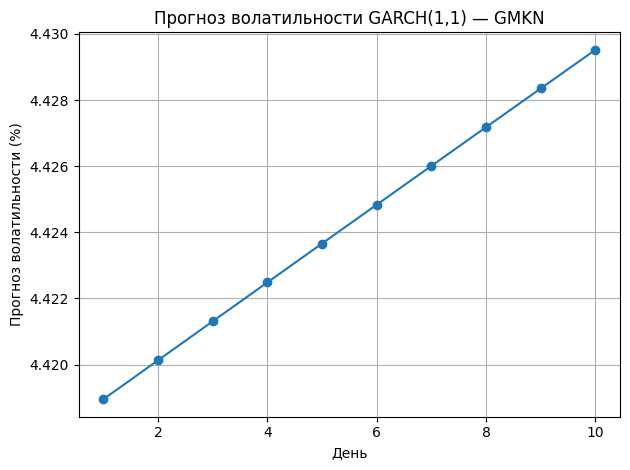

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# Выбор актива
ticker = 'GMKN'
returns_series = returns[ticker].dropna() * 100  # перевод в проценты для стабильной работы модели

# Обучение модели GARCH(1,1)
model = arch_model(returns_series, vol='Garch', p=1, q=1)
model_fit = model.fit(disp='off')

# Прогноз волатильности на 10 дней
forecast_horizon = 10
forecast = model_fit.forecast(horizon=forecast_horizon)
predicted_volatility = np.sqrt(forecast.variance.values[-1, :])

# Отображение результатов
print(f"Прогнозируемая волатильность ({ticker}) на следующие {forecast_horizon} дней:")
for i, vol in enumerate(predicted_volatility, 1):
    print(f"День {i}: {vol:.4f}%")

# Построение графика прогноза волатильности
plt.plot(range(1, forecast_horizon + 1), predicted_volatility, marker='o')
plt.title(f'Прогноз волатильности GARCH(1,1) — {ticker}')
plt.xlabel('День')
plt.ylabel('Прогноз волатильности (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

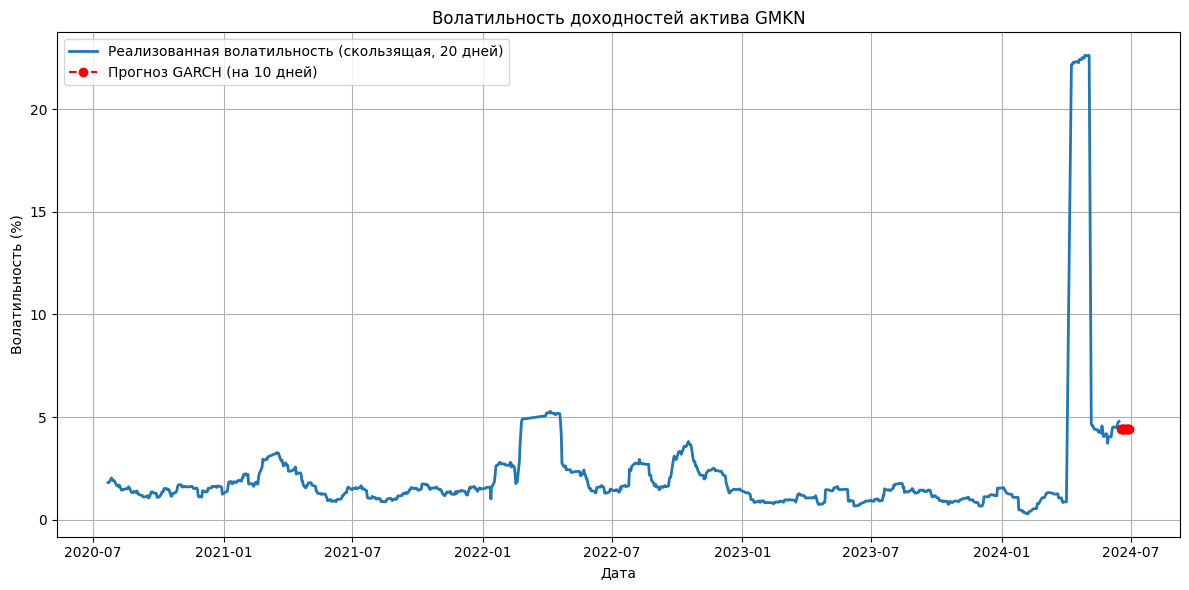

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# Выбор тикера
ticker = 'GMKN'
returns_series = returns[ticker].dropna() * 100  # в процентах

# 1. Реализованная скользящая волатильность (по окну 20 дней)
window = 20
rolling_volatility = returns_series.rolling(window=window).std()

# 2. Обучение модели GARCH(1,1)
model = arch_model(returns_series, vol='Garch', p=1, q=1)
model_fit = model.fit(disp='off')

# Прогноз волатильности на 10 дней вперёд
forecast_horizon = 10
forecast = model_fit.forecast(horizon=forecast_horizon)
predicted_vol = np.sqrt(forecast.variance.values[-1, :])  # в процентах

# Создание датафрейма для объединённого графика
last_date = returns_series.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='B')
forecast_df = pd.Series(predicted_vol, index=future_dates)

# 3. Построение объединённого графика
plt.figure(figsize=(12, 6))
plt.plot(rolling_volatility, label='Реализованная волатильность (скользящая, 20 дней)', linewidth=2)
plt.plot(forecast_df, label='Прогноз GARCH (на 10 дней)', linestyle='--', marker='o', color='red')
plt.title(f"Волатильность доходностей актива {ticker}")
plt.xlabel("Дата")
plt.ylabel("Волатильность (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

🔍 Обработка: GMKN


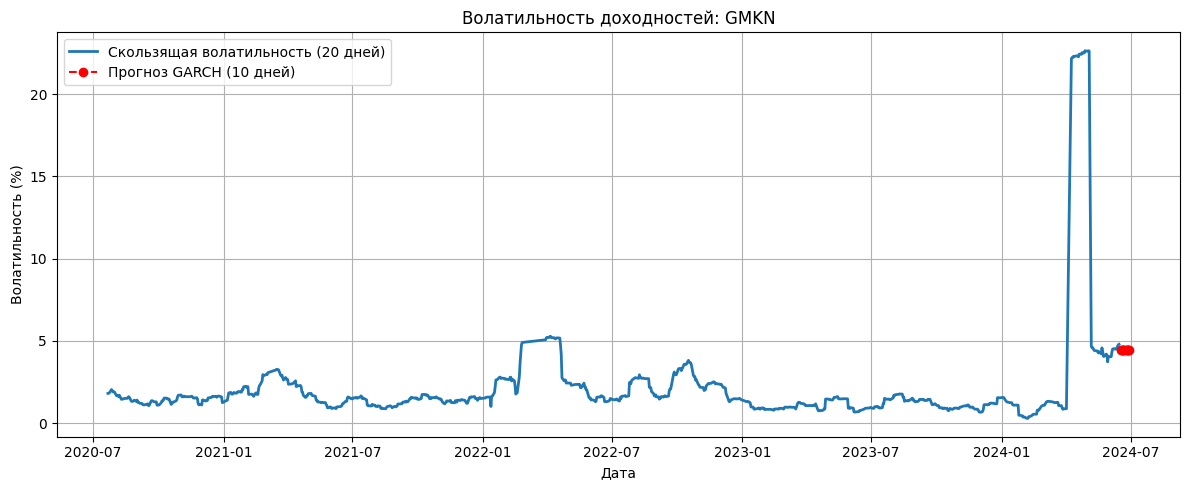

🔍 Обработка: SBER


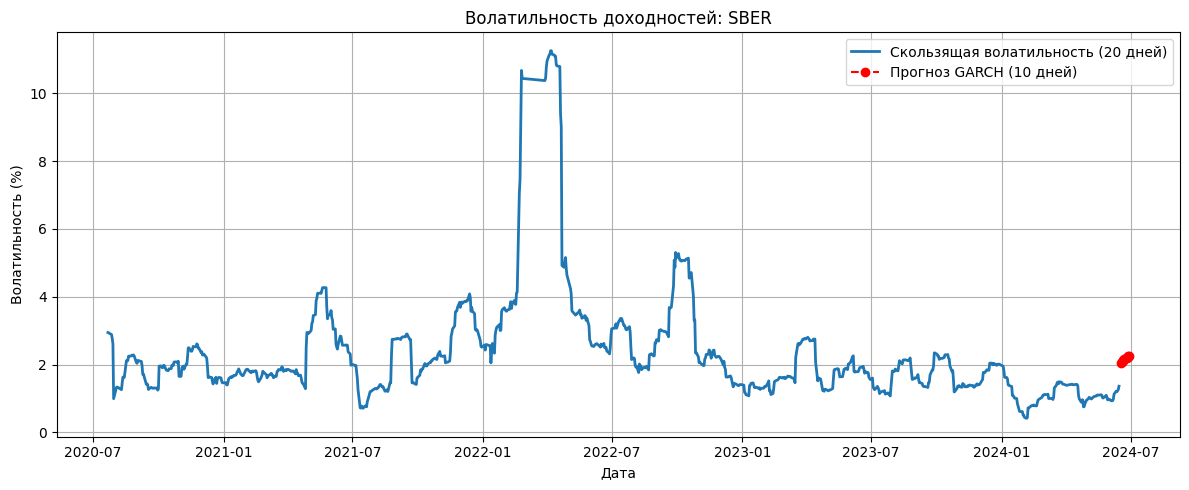

🔍 Обработка: YNDX


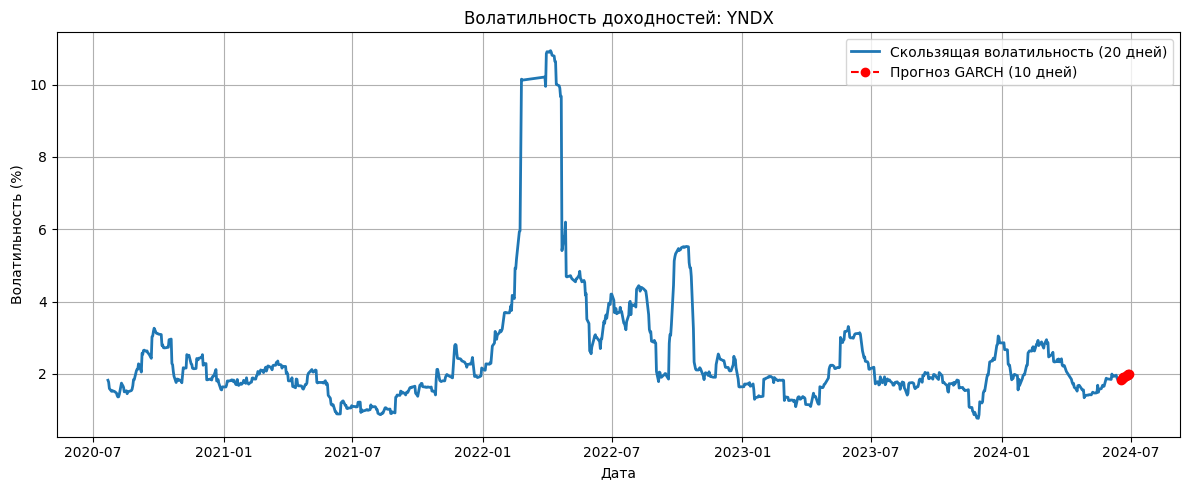

🔍 Обработка: MGNT


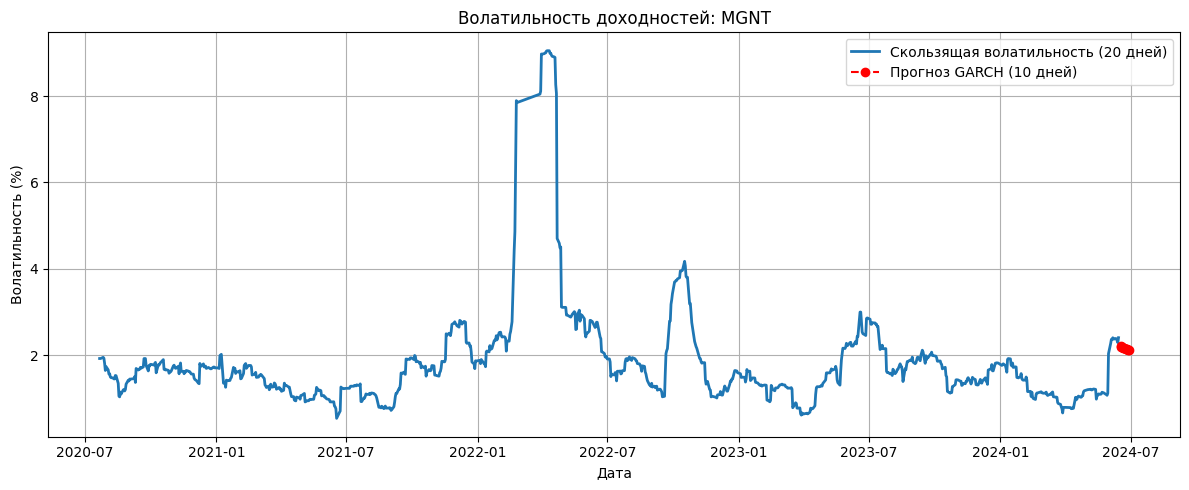

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# 🔧 Список тикеров
tickers = ['GMKN', 'SBER', 'YNDX', 'MGNT']

# Параметры
window = 20
forecast_horizon = 10

# Построение графиков
for ticker in tickers:
    print(f"🔍 Обработка: {ticker}")

    # Доходности в процентах
    returns_series = returns[ticker].dropna() * 100

    # 1. Реализованная волатильность (скользящее окно)
    rolling_vol = returns_series.rolling(window=window).std()

    # 2. GARCH-прогноз
    model = arch_model(returns_series, vol='Garch', p=1, q=1)
    model_fit = model.fit(disp='off')
    forecast = model_fit.forecast(horizon=forecast_horizon)
    predicted_vol = np.sqrt(forecast.variance.values[-1, :])  # стандартное отклонение (%)

    # 3. Построение графика
    last_date = returns_series.index[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='B')
    forecast_series = pd.Series(predicted_vol, index=future_dates)

    # График
    plt.figure(figsize=(12, 5))
    plt.plot(rolling_vol, label='Скользящая волатильность (20 дней)', linewidth=2)
    plt.plot(forecast_series, 'r--o', label='Прогноз GARCH (10 дней)')
    plt.title(f"Волатильность доходностей: {ticker}")
    plt.xlabel("Дата")
    plt.ylabel("Волатильность (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Зависимая переменная (предсказуемая) — GMKN
y = returns['GMKN'].dropna()

# Независимые переменные — остальные активы
X = returns.drop(columns='GMKN').loc[y.index]  # убираем GMKN и синхронизируем индексы

# Добавим константу (intercept) в модель
X = sm.add_constant(X)

# Построим модель
model = sm.OLS(y, X).fit()

# Вывод результатов
print(model.summary())